In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [29]:
# ============================================================
# 2. LOAD DATA
# ============================================================
app = pd.read_csv(r"C:\Users\nikhi\Data Science\Bank_loan_Analysis\application_data.csv")
prev = pd.read_csv(r"C:\Users\nikhi\Data Science\Bank_loan_Analysis\previous_application.csv")

In [30]:
print("Application shape:", app.shape)
print("Previous Application shape:", prev.shape)

Application shape: (307511, 122)
Previous Application shape: (1670214, 37)


In [31]:
# ============================================================
# 3. BASIC CLEANING
# ============================================================

app.replace(365243, np.nan, inplace=True)
prev.replace(365243, np.nan, inplace=True)

# Convert DAYS to YEARS
for col in app.columns:
    if "DAYS" in col:
        app[col] = abs(app[col]) / 365

for col in prev.columns:
    if "DAYS" in col:
        prev[col] = abs(prev[col]) / 365

app.rename(columns=lambda x: x.replace("DAYS_", "YEARS_"), inplace=True)
prev.rename(columns=lambda x: x.replace("DAYS_", "YEARS_"), inplace=True)

In [32]:
# ============================================================
# 4. FINANCIAL BURDEN FEATURES
# ============================================================

app["CREDIT_INCOME_RATIO"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"]
app["ANNUITY_INCOME_RATIO"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"]
app["CREDIT_GOODS_RATIO"] = app["AMT_CREDIT"] / app["AMT_GOODS_PRICE"]

app["EMPLOYMENT_STABILITY"] = app["YEARS_EMPLOYED"] / app["YEARS_BIRTH"]

EMP_STABILITY_SEG
Low          0.068355
Moderate     0.106311
High         0.087373
Very High    0.060876
Name: TARGET, dtype: float64


C:\Users\nikhi\AppData\Local\Temp\ipykernel_17628\2745928155.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_default = df.groupby("EMP_STABILITY_SEG")["TARGET"].mean()


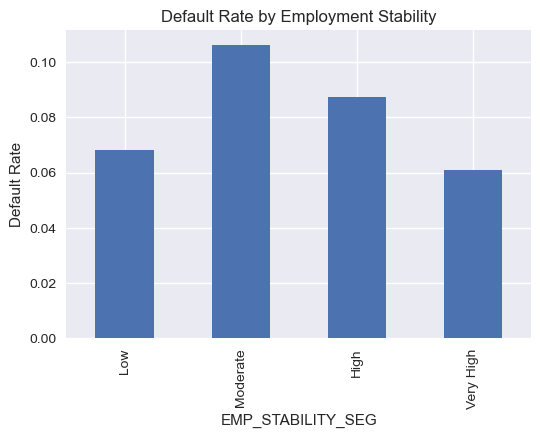

In [63]:
df["EMP_STABILITY_SEG"] = pd.qcut(
    df["EMPLOYMENT_STABILITY"], 4,
    labels=["Low", "Moderate", "High", "Very High"]
)

emp_default = df.groupby("EMP_STABILITY_SEG")["TARGET"].mean()
print(emp_default)

emp_default.plot(kind="bar",figsize=(6,4))
plt.title("Default Rate by Employment Stability")
plt.ylabel("Default Rate")
plt.show()

In [33]:
# ============================================================
# 5. PREVIOUS LOAN BEHAVIOR AGGREGATION
# ============================================================

prev_agg = prev.groupby("SK_ID_CURR").agg(
    TOTAL_PREV_APPS=("SK_ID_PREV", "count"),
    PREV_APPROVED=("NAME_CONTRACT_STATUS", lambda x: (x=="Approved").sum()),
    PREV_REFUSED=("NAME_CONTRACT_STATUS", lambda x: (x=="Refused").sum()),
    AVG_PREV_CREDIT=("AMT_CREDIT", "mean"),
    MAX_PREV_CREDIT=("AMT_CREDIT", "max")
).reset_index()

prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED"] / prev_agg["TOTAL_PREV_APPS"]
)

prev_agg["REJECTION_RATE"] = (
    prev_agg["PREV_REFUSED"] / prev_agg["TOTAL_PREV_APPS"]
)

# Merge
df = app.merge(prev_agg, on="SK_ID_CURR", how="left")
df.fillna(0, inplace=True)

In [43]:
# ============================================================
# 6. SEGMENT CREATION (QUANTILE-BASED)
# ============================================================

df["INCOME_SEGMENT"] = pd.qcut(df["AMT_INCOME_TOTAL"], 4,
                               labels=["Low", "Lower-Mid", "Upper-Mid", "High"])

df["CREDIT_BURDEN_SEG"] = pd.qcut(df["CREDIT_INCOME_RATIO"], 4,
                                  labels=["Low", "Moderate", "High", "Very High"])

df["HISTORICAL_REJECTION_SEG"] = pd.cut(df["REJECTION_RATE"],bins=[-0.01, 0.01, 0.25, 0.50, 1],labels=["Low", "Moderate", "High", "Very High"])



Default Rate by INCOME_SEGMENT
INCOME_SEGMENT
Lower-Mid    0.085311
Upper-Mid    0.083953
Low          0.083945
High         0.069096
Name: TARGET, dtype: float64


C:\Users\nikhi\AppData\Local\Temp\ipykernel_17628\707884403.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby(segment_col)["TARGET"].mean().sort_values(ascending=False)


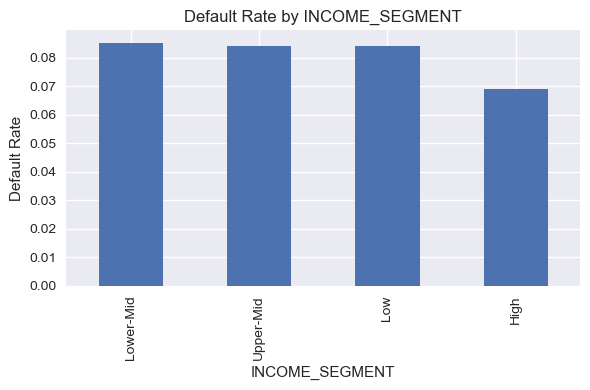

C:\Users\nikhi\AppData\Local\Temp\ipykernel_17628\707884403.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby(segment_col)["TARGET"].mean().sort_values(ascending=False)



Default Rate by CREDIT_BURDEN_SEG
CREDIT_BURDEN_SEG
High         0.087436
Moderate     0.087219
Low          0.074622
Very High    0.073650
Name: TARGET, dtype: float64


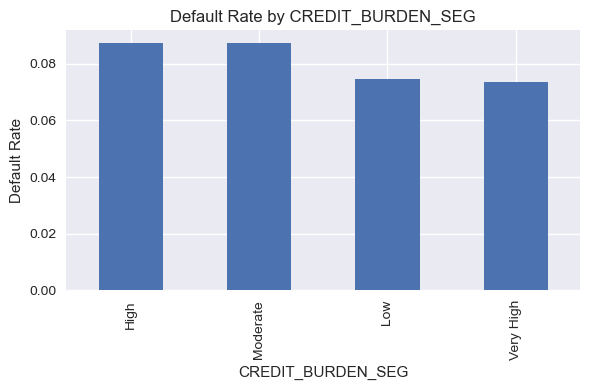

C:\Users\nikhi\AppData\Local\Temp\ipykernel_17628\707884403.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby(segment_col)["TARGET"].mean().sort_values(ascending=False)



Default Rate by HISTORICAL_REJECTION_SEG
HISTORICAL_REJECTION_SEG
Very High    0.159258
High         0.113299
Moderate     0.081144
Low          0.069845
Name: TARGET, dtype: float64


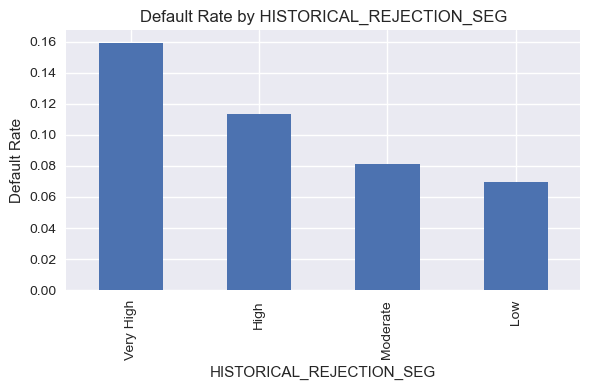

In [51]:
# ============================================================
# 7. DEFAULT RATE BY SEGMENTS
# ============================================================

def segment_default_rate(segment_col):
    seg = df.groupby(segment_col)["TARGET"].mean().sort_values(ascending=False)
    print("\nDefault Rate by", segment_col)
    print(seg)

    plt.figure(figsize=(6,4))   # 👈 adjust width, height here
    seg.plot(kind="bar")
    plt.ylabel("Default Rate")
    plt.title(f"Default Rate by {segment_col}")
    plt.tight_layout()
    plt.show()


segment_default_rate("INCOME_SEGMENT")
segment_default_rate("CREDIT_BURDEN_SEG")
segment_default_rate("HISTORICAL_REJECTION_SEG")


Default Heatmap (Income vs Credit Burden):
INCOME_SEGMENT          Low  Lower-Mid  Upper-Mid      High
CREDIT_BURDEN_SEG                                          
Low                0.066445   0.074501   0.078870  0.076834
Moderate           0.082034   0.096613   0.101410  0.075887
High               0.098811   0.101803   0.088197  0.061052
Very High          0.084836   0.071438   0.066530  0.046284


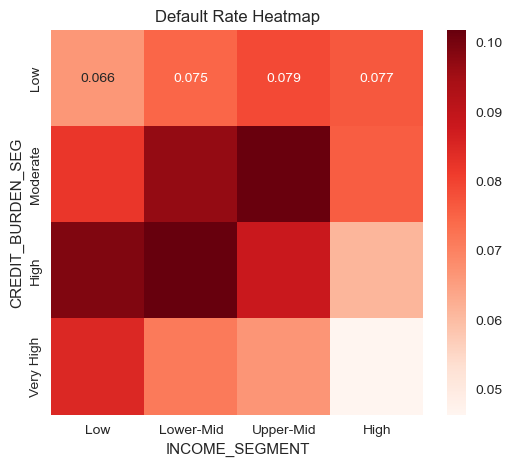

In [50]:
# ============================================================
# 8. MULTI-DIMENSIONAL RISK CROSS ANALYSIS
# ============================================================

pivot = pd.pivot_table(
    df,
    values="TARGET",
    index="CREDIT_BURDEN_SEG",
    columns="INCOME_SEGMENT",
    aggfunc="mean"
)

print("\nDefault Heatmap (Income vs Credit Burden):")
print(pivot)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Default Rate Heatmap")
plt.show()


Default Rate by RISK_GROUP
RISK_GROUP
Very High Risk    0.095365
High              0.082061
Moderate          0.078205
Low Risk          0.067286
Name: TARGET, dtype: float64


C:\Users\nikhi\AppData\Local\Temp\ipykernel_17628\1567740729.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg = df.groupby(segment_col)["TARGET"].mean().sort_values(ascending=False)


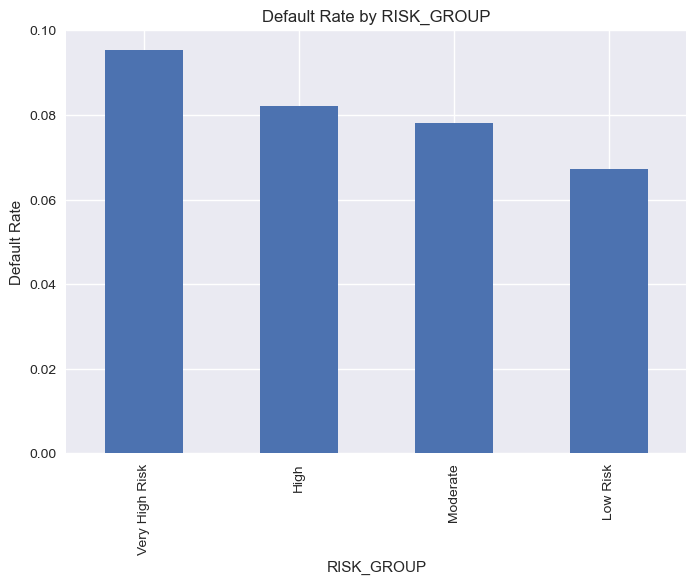

In [46]:
# ============================================================
# 9. BEHAVIORAL RISK INTENSITY SCORE (ANALYTICAL, NOT ML)
# ============================================================

df["RISK_INTENSITY_SCORE"] = (
    df["CREDIT_INCOME_RATIO"].rank(pct=True) +
    df["REJECTION_RATE"].rank(pct=True) -
    df["AMT_INCOME_TOTAL"].rank(pct=True)
)

df["RISK_GROUP"] = pd.qcut(df["RISK_INTENSITY_SCORE"], 4,
                           labels=["Low Risk", "Moderate", "High", "Very High Risk"])

segment_default_rate("RISK_GROUP")




Default Rate by Application Frequency & Approval Rate:
APPROVAL_RATE_SEG       Low  Moderate      High  Very High
APP_FREQ_SEG                                              
Low                0.060159       NaN  0.096708   0.079042
Moderate           0.115385       NaN  0.122445   0.071247
High               0.111111  0.135487  0.103309   0.063778
Very High          0.250000  0.153350  0.104965   0.065997


C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


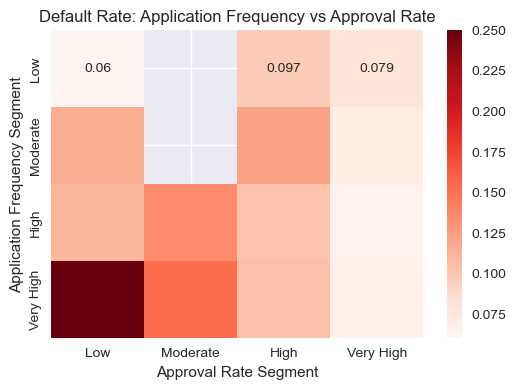

In [57]:
df["APP_FREQ_SEG"] = pd.qcut(df["TOTAL_PREV_APPS"], 4,
                             labels=["Low", "Moderate", "High", "Very High"])

df["APPROVAL_RATE_SEG"] = pd.cut(df["PREV_APPROVAL_RATE"] ,bins=[-0.01, 0.01, 0.25, 0.50, 1],
                                  labels=["Low", "Moderate", "High", "Very High"])

# Create pivot table
pivot_behavior = pd.pivot_table(
    df,
    values="TARGET",
    index="APP_FREQ_SEG",
    columns="APPROVAL_RATE_SEG",
    aggfunc="mean"
)

print("\nDefault Rate by Application Frequency & Approval Rate:")
print(pivot_behavior)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(pivot_behavior, annot=True, cmap="Reds")
plt.title("Default Rate: Application Frequency vs Approval Rate")
plt.ylabel("Application Frequency Segment")
plt.xlabel("Approval Rate Segment")
plt.show()

In [47]:
# ============================================================
# 10. FINAL RISK PROFILE SUMMARY
# ============================================================

print("\n===== HIGH RISK CUSTOMER PROFILE =====")
high_risk = df[df["RISK_GROUP"]=="Very High Risk"]

print("Average Income:", high_risk["AMT_INCOME_TOTAL"].mean())
print("Average Credit-Income Ratio:", high_risk["CREDIT_INCOME_RATIO"].mean())
print("Average Rejection Rate:", high_risk["REJECTION_RATE"].mean())
print("Default Rate:", high_risk["TARGET"].mean())


===== HIGH RISK CUSTOMER PROFILE =====
Average Income: 104134.08540736018
Average Credit-Income Ratio: 6.481831435888551
Average Rejection Rate: 0.1960425250471111
Default Rate: 0.0953650826688174


In [48]:
print("\nAnalysis Complete.")


Analysis Complete.
